# Stage 4 — Results analysis

Loads the feature table, runs the probe protocol and the full statistical suite (`sec:analysis_method`) for one experiment (E1/E2/E3), and produces the thesis figures:

- per-layer folded AUROC profiles with the permutation-scan threshold,
- test AUROC with bootstrap CI (base vs full probe),
- ΔAUROC paired bootstrap (the contribution claim),
- β-sensitivity curve (E1 only, from cached score tensors),
- per-category descriptive table.

Confirmatory family = exactly {discrimination, contribution}, Bonferroni at family α = 0.05 (decisions read the 97.5% CIs). Everything else is exploratory/descriptive. Every figure is saved to `results/<experiment>/figures/`.

In [22]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "configs").exists():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

from energy_llm.config import load_config

EXPERIMENT = "e1"  # e1 | e2 | e3
cfg = load_config(REPO_ROOT / f"configs/{EXPERIMENT}.yaml")
cfg.output_dir = str(REPO_ROOT / cfg.output_dir)
FIG_DIR = cfg.figures_dir
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
GROUP_LABELS = {"delta_energy": r"$\Delta E$", "delta_norm_entropy": r"$\Delta\bar{H}$",
                "mean_js": r"$\overline{\mathrm{JS}}$",
                "mean_hellinger_sq": r"$\overline{H^2_{\mathrm{Hel}}}$"}

import json
cal = json.loads((REPO_ROOT / f"results/{EXPERIMENT}/calibration/calibration.json").read_text())
cfg.calibration.beta_star = cal["beta_star"]
print(f"experiment: {cfg.name}   beta* = {cfg.calibration.beta_star}")

experiment: e1_qwen_truthfulqa   beta* = 1.9578453524806456


## Load features and labels

In [23]:
from energy_llm.features import infer_n_layers, phi_matrix, baseline_matrix, PHI_GROUPS
from energy_llm.labeling import load_labels

# Leer features ya calculados en HPC
df = pd.read_csv(REPO_ROOT / f"results/{EXPERIMENT}/features/features.csv")
labels = json.loads((REPO_ROOT / f"results/{EXPERIMENT}/labels.json").read_text())
df["is_hallucination"] = df["sample_id"].map(labels)
df = df[df["is_hallucination"].notna()].reset_index(drop=True)

n_layers = infer_n_layers(df)
y = df["is_hallucination"].to_numpy(dtype=int)
X_phi = phi_matrix(df, n_layers)
X_base = baseline_matrix(df)

print(f"labelled samples: {len(df)}   L = {n_layers}   phi dim = {X_phi.shape[1]}")
print(f"hallucination rate: {y.mean():.3f}")

labelled samples: 817   L = 36   phi dim = 144
hallucination rate: 0.483


## Locked split and probes

70/15/15 stratified at seed 42; calibration ids forced into train; test split hashed and locked. Base probe = baselines only; full probe = baselines + φ, identical protocol.

In [24]:
split_path = REPO_ROOT / f"results/{EXPERIMENT}/split.json"
print(f"split.json exists: {split_path.exists()}")
print(f"calibration.json exists: {(REPO_ROOT / f'results/{EXPERIMENT}/calibration/calibration.json').exists()}")

split.json exists: True
calibration.json exists: True


In [25]:
from energy_llm.io_artifacts import load_json
from energy_llm.probe import make_locked_splits, run_base_and_full_probes

cal_path = cfg.calibration_dir / "calibration.json"
cal_ids = load_json(cal_path)["calibration_sample_ids"] if cal_path.exists() else []

splits = make_locked_splits(
    df["sample_id"].tolist(), y, cfg.out / "split.json",
    seed=cfg.seed, ratios=tuple(cfg.probe.split), force_train_ids=cal_ids,
)
idx = splits.index_of(df["sample_id"].tolist())
print({k: len(v) for k, v in idx.items()}, "test hash:", splits.test_hash[:12], "…")

probes = run_base_and_full_probes(
    X_base, X_phi, y, idx, c_grid=cfg.probe.c_grid,
    inner_cv_folds=cfg.probe.inner_cv_folds,
    outer_cv_folds=cfg.probe.outer_cv_folds, seed=cfg.seed,
)
for kind in ("base", "full"):
    p = probes[kind]
    print(f"{kind:4s}  C={p['best_c']:<5}  test AUROC={p['test_auroc']:.4f}  "
          f"outer 5-fold CV {p['outer_cv_auroc_mean']:.4f} ± {p['outer_cv_auroc_std']:.4f} (descriptive)")

{'train': 571, 'val': 123, 'test': 123} test hash: ceb27baec598 …
base  C=10.0   test AUROC=0.4717  outer 5-fold CV 0.5818 ± 0.0553 (descriptive)
full  C=0.01   test AUROC=0.6669  outer 5-fold CV 0.6890 ± 0.0359 (descriptive)


## Confirmatory claims: discrimination and contribution

In [26]:
from energy_llm.stats import bootstrap_auroc_ci, paired_bootstrap_delta_auroc

y_test = probes["full"]["y_test"]
discrimination = bootstrap_auroc_ci(
    y_test, probes["full"]["test_scores"],
    n_bootstrap=cfg.stats.n_bootstrap, seed=cfg.seed)
contribution = paired_bootstrap_delta_auroc(
    y_test, probes["full"]["test_scores"], probes["base"]["test_scores"],
    n_bootstrap=cfg.stats.n_bootstrap, seed=cfg.seed)

print(f"DISCRIMINATION  AUROC = {discrimination['auroc']:.4f}")
print(f"  95%   CI {discrimination['ci_0.950']}   -> claim: {discrimination['discriminates_95']}")
print(f"  97.5% CI {discrimination['ci_0.975']}   -> Bonferroni: {discrimination['discriminates_bonferroni']}")
print(f"CONTRIBUTION    dAUROC = {contribution['delta_auroc']:.4f}  "
      f"(full {contribution['auroc_full']:.4f} vs base {contribution['auroc_base']:.4f})")
print(f"  95%   CI {contribution['ci_0.950']}   -> claim: {contribution['contributes_95']}")
print(f"  97.5% CI {contribution['ci_0.975']}   -> Bonferroni: {contribution['contributes_bonferroni']}")

DISCRIMINATION  AUROC = 0.6669
  95%   CI [0.5698105358571588, 0.758690284487386]   -> claim: True
  97.5% CI [0.5556977688658723, 0.7722222222222223]   -> Bonferroni: True
CONTRIBUTION    dAUROC = 0.1952  (full 0.6669 vs base 0.4717)
  95%   CI [0.05767445812743481, 0.33200638553643264]   -> claim: True
  97.5% CI [0.03704678492458341, 0.3517531440456966]   -> Bonferroni: True


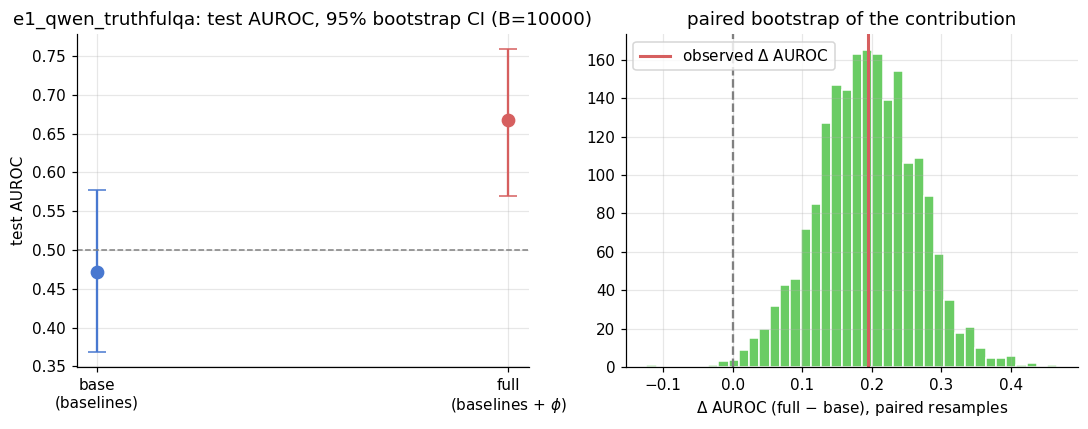

In [31]:
base_ci = bootstrap_auroc_ci(y_test, probes["base"]["test_scores"],
                             n_bootstrap=cfg.stats.n_bootstrap, seed=cfg.seed)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for i, (name, ci) in enumerate([("base\n(baselines)", base_ci),
                                ("full\n(baselines + $\\phi$)", discrimination)]):
    lo, hi = ci["ci_0.950"]
    axes[0].errorbar(i, ci["auroc"], yerr=[[ci["auroc"] - lo], [hi - ci["auroc"]]],
                     fmt="o", capsize=6, markersize=8,
                     color=["#4878d0", "#d65f5f"][i])
axes[0].axhline(0.5, ls="--", c="gray", lw=1)
axes[0].set_xticks([0, 1], ["base\n(baselines)", "full\n(baselines + $\\phi$)"])
axes[0].set_ylabel("test AUROC")
axes[0].set_title(f"{cfg.name}: test AUROC, 95% bootstrap CI (B={cfg.stats.n_bootstrap})")

rng = np.random.default_rng(cfg.seed)
from energy_llm.stats import _resample_indices, auroc as _auroc
draws = np.array([(lambda i: _auroc(y_test[i], probes['full']['test_scores'][i])
                   - _auroc(y_test[i], probes['base']['test_scores'][i]))
                  (_resample_indices(rng, y_test)) for _ in range(2000)])
axes[1].hist(draws, bins=40, color="#6acc64", edgecolor="white")
axes[1].axvline(0, ls="--", c="gray")
axes[1].axvline(contribution["delta_auroc"], c="#d65f5f", lw=2, label="observed $\\Delta$ AUROC")
axes[1].set_xlabel("$\\Delta$ AUROC (full $-$ base), paired resamples")
axes[1].set_title("paired bootstrap of the contribution")
axes[1].legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "test_auroc_and_delta.png", dpi=150)
plt.show()

## Depth-axis localisation (exploratory)

Folded per-layer AUROC `max(AUROC, 1−AUROC)` for each of the 4 φ features, against the permutation null of the scan maximum over ALL layer-feature pairs (B_perm = 1000, 95th percentile).

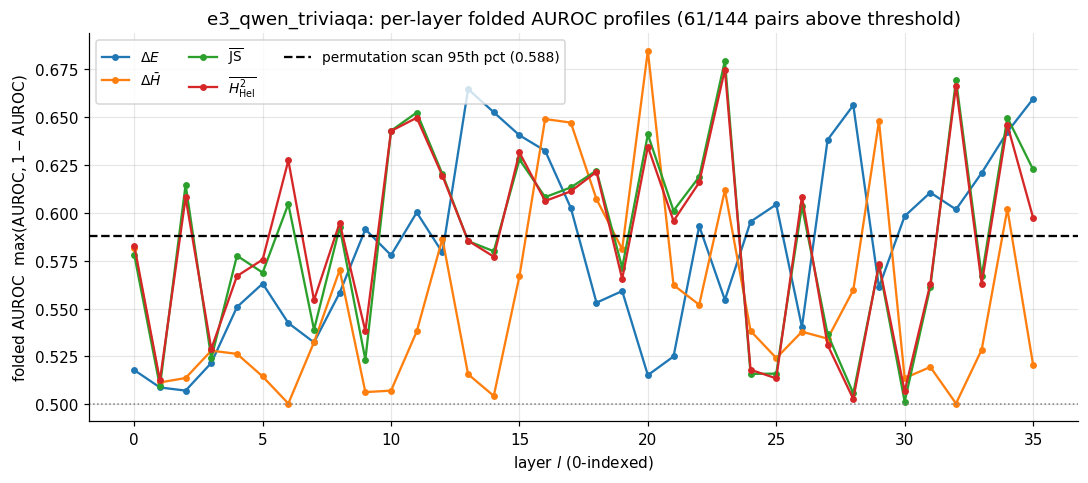

In [17]:
from energy_llm.stats import permutation_scan_threshold

scan = permutation_scan_threshold(X_phi, y, n_permutation=cfg.stats.n_permutation,
                                  seed=cfg.seed)
observed = scan["observed_folded_auroc"].reshape(len(PHI_GROUPS), n_layers)

fig, ax = plt.subplots(figsize=(10, 4.5))
for g, group in enumerate(PHI_GROUPS):
    ax.plot(range(n_layers), observed[g], marker="o", ms=3.5, label=GROUP_LABELS[group])
ax.axhline(scan["scan_threshold"], color="black", ls="--", lw=1.5,
           label=f"permutation scan 95th pct ({scan['scan_threshold']:.3f})")
ax.axhline(0.5, color="gray", ls=":", lw=1)
ax.set_xlabel("layer $l$ (0-indexed)")
ax.set_ylabel("folded AUROC  $\\max(\\mathrm{AUROC}, 1-\\mathrm{AUROC})$")
ax.set_title(f"{cfg.name}: per-layer folded AUROC profiles "
             f"({scan['n_significant']}/{4 * n_layers} pairs above threshold)")
ax.legend(ncol=3, fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / "per_layer_folded_auroc.png", dpi=150)
plt.show()

## β sensitivity from precomputed CSV (descriptive)

Two-panel figure from `beta_sensitivity.csv` (generated by
`scripts/run_beta_sensitivity.py`): left = mean Δ*H̄* per sample vs β split
by hallucination class; right = full-probe AUROC vs β with β★ marked.
Run `sbatch hpc/beta_sensitivity.sbatch configs/e1.yaml` to produce the CSV.

In [ ]:
beta_sensitivity_csv = cfg.out / "beta_sensitivity.csv"

if beta_sensitivity_csv.exists():
    bs = pd.read_csv(beta_sensitivity_csv)

    # Left subplot: mean Delta H_bar vs beta, split by hallucination class.
    agg = (
        bs.dropna(subset=["is_hallucination"])
        .groupby(["beta", "is_hallucination"])["mean_delta_hbar"]
        .mean()
        .reset_index()
    )
    # Right subplot: unique (beta, probe_auroc) pairs.
    auroc_curve = (
        bs.drop_duplicates("beta")[["beta", "probe_auroc"]].sort_values("beta")
    )

    fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(12, 4.5))

    _CLASS_STYLE = {1: ("hallucination", "#d65f5f"), 0: ("supported", "#4878d0")}
    for label, grp in agg.groupby("is_hallucination"):
        name, color = _CLASS_STYLE.get(int(label), (str(label), "gray"))
        ax_l.plot(grp["beta"], grp["mean_delta_hbar"], marker="o", ms=4,
                  label=name, color=color)
    ax_l.axvline(cfg.calibration.beta_star, color="gray", ls="--", lw=1.2,
                 label=rf"$\beta^\star$ = {cfg.calibration.beta_star:.2f}")
    ax_l.set_xscale("log")
    ax_l.set_xlabel(r"$\beta$")
    ax_l.set_ylabel(r"mean $\Delta\bar{H}$ (mean over layers)")
    ax_l.set_title(f"{cfg.name}: mean $\\Delta\\bar{{H}}$ vs $\\beta$")
    ax_l.legend(fontsize=9)

    ax_r.plot(auroc_curve["beta"], auroc_curve["probe_auroc"],
              marker="o", ms=5, color="#6acc64")
    ax_r.axvline(cfg.calibration.beta_star, color="#d65f5f", ls="--", lw=1.5,
                 label=rf"$\beta^\star$ = {cfg.calibration.beta_star:.2f}")
    ax_r.axhline(0.5, color="gray", ls=":", lw=1)
    ax_r.set_xscale("log")
    ax_r.set_xlabel(r"$\beta$")
    ax_r.set_ylabel("full-probe AUROC")
    ax_r.set_title(f"{cfg.name}: probe AUROC vs $\\beta$ (descriptive)")
    ax_r.legend(fontsize=9)

    fig.tight_layout()
    fig.savefig(FIG_DIR / "beta_sensitivity.png", dpi=150)
    plt.show()
else:
    print(f"beta_sensitivity.csv not found at {beta_sensitivity_csv} — "
          "run scripts/run_beta_sensitivity.py --config configs/e1.yaml first")

## Single-feature unsupervised AUROC (best layer per feature, no fitting)

In [18]:
rows = []
for g, group in enumerate(PHI_GROUPS):
    best_l = int(np.argmax(observed[g]))
    rows.append({"feature": group, "best_layer": best_l,
                 "folded_auroc": observed[g, best_l],
                 "above_scan_threshold": observed[g, best_l] > scan["scan_threshold"]})
single_feature_table = pd.DataFrame(rows)
single_feature_table

,feature,best_layer,folded_auroc,above_scan_threshold
0,delta_energy,13,0.664719,True
1,delta_norm_entropy,20,0.684755,True
2,mean_js,23,0.679670,True
3,mean_hellinger_sq,23,0.674971,True


## Per-category descriptive AUROC (largest TruthfulQA categories, test split)

In [32]:
from energy_llm.stats import per_category_auroc

test_mask = np.isin(np.arange(len(df)), idx["test"])
category_rows = per_category_auroc(
    df.loc[test_mask, "category"].tolist(), y[test_mask],
    probes["full"]["test_scores"], min_n=10)
category_table = pd.DataFrame(category_rows)
category_table.to_csv(FIG_DIR / "per_category_auroc.csv", index=False)
category_table

,category,n,hallucination_rate,auroc
0,Misconceptions,12,0.333333,0.8125
1,Sociology,11,0.454545,0.7000


## β sensitivity (descriptive, E1 only)

Recomputes all features over the β grid from the cached score tensors — **no forward passes** — and reruns the full-probe protocol on the identical locked split at each β.

In [ ]:
from energy_llm.features import build_feature_table_at_beta
from energy_llm.probe import run_probe_protocol

has_cache = any(cfg.trajectories_dir.glob("*_retrieval_scores.npz"))
beta_curve = []
if not has_cache:
    print("no cached score tensors in this run (cache_score_tensors=false) — skipping")
else:
    sid_order = df["sample_id"].tolist()
    for beta in cfg.calibration.beta_grid:
        df_b = build_feature_table_at_beta(cfg.trajectories_dir, float(beta), labels=labels)
        df_b = df_b.set_index("sample_id").reindex(sid_order).reset_index()
        Xb = np.hstack([df_b[["seq_logprob", "token_entropy_mean"]].to_numpy(float),
                        phi_matrix(df_b, n_layers)])
        res = run_probe_protocol(Xb, y, idx, c_grid=cfg.probe.c_grid,
                                 inner_cv_folds=cfg.probe.inner_cv_folds,
                                 outer_cv_folds=cfg.probe.outer_cv_folds, seed=cfg.seed)
        beta_curve.append({"beta": float(beta), "test_auroc": res["test_auroc"]})
        print(f"beta={beta:<6} test AUROC={res['test_auroc']:.4f}")

if beta_curve:
    bc = pd.DataFrame(beta_curve)
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(bc["beta"], bc["test_auroc"], marker="o", color="#4878d0")
    ax.axvline(cfg.calibration.beta_star, color="#d65f5f", ls="--",
               label=f"$\\beta^\\star$ = {cfg.calibration.beta_star:.2f}")
    ax.axhline(0.5, color="gray", ls=":", lw=1)
    ax.set_xscale("log")
    ax.set_xlabel(r"$\beta$")
    ax.set_ylabel("full-probe test AUROC")
    ax.set_title(f"{cfg.name}: sensitivity of the test AUROC to $\\beta$ (descriptive)")
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIG_DIR / "beta_sensitivity.png", dpi=150)
    plt.show()

## Save the summary

In [33]:
from energy_llm.io_artifacts import save_json_atomic

summary = {
    "experiment": cfg.name,
    "beta_star": cfg.calibration.beta_star,
    "n_labelled": int(len(df)),
    "hallucination_rate": float(y.mean()),
    "split_sizes": {k: int(len(v)) for k, v in idx.items()},
    "test_split_hash": splits.test_hash,
    "base": {"test_auroc": probes["base"]["test_auroc"], "best_c": probes["base"]["best_c"],
             "ci_95": base_ci["ci_0.950"]},
    "full": {"test_auroc": probes["full"]["test_auroc"], "best_c": probes["full"]["best_c"],
             "ci_95": discrimination["ci_0.950"], "ci_97_5": discrimination["ci_0.975"]},
    "delta_auroc": {"point": contribution["delta_auroc"],
                    "ci_95": contribution["ci_0.950"], "ci_97_5": contribution["ci_0.975"]},
    "confirmatory_bonferroni": {
        "discrimination": bool(discrimination["discriminates_bonferroni"]),
        "contribution": bool(contribution["contributes_bonferroni"]),
    },
    "scan_threshold": scan["scan_threshold"],
    "n_layer_feature_pairs_significant": int(scan["n_significant"]),
    "beta_sensitivity": [],
    "per_category": category_rows,
}
save_json_atomic(cfg.out / "analysis_summary.json", summary)
print(f"written: {cfg.out / 'analysis_summary.json'}")
print(f"figures: {sorted(p.name for p in FIG_DIR.iterdir())}")

written: /home/brandon/energy_llm/results/e1/analysis_summary.json
figures: ['label_distribution.png', 'label_distribution_all.png', 'per_category_auroc.csv', 'per_layer_folded_auroc.png', 'test_auroc_and_delta.png']
